---
## Phase 1: Raw Data Exploration
Before any cleaning, we inspect the raw data to understand distributions, spot impossible values, and identify dirty categorical entries.

### 1.1 Summary Statistics
Look for:
- **Impossible values**: min of 0 sqft for a job size, or negative distances
- **Huge ranges**: max values that are orders of magnitude above the median
- **Suspicious mins/maxes**: could indicate data entry errors or sentinel values (e.g. 99999)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("leads.csv")
print("Numeric summary statistics:")
df.describe()

Numeric summary statistics:


,estimated_job_size_sqft,distance_to_queens_km
count,1190.000000,1221.000000
mean,1414.468067,3.612817
std,1441.337856,1.894495
min,0.000000,0.200000
25%,854.250000,2.210000
50%,1290.500000,3.630000
75%,1817.750000,4.950000
max,45000.000000,9.760000


### 1.2 Distribution of estimated_job_size_sqft
Are there extreme outliers or impossible values like 0 or 99999?

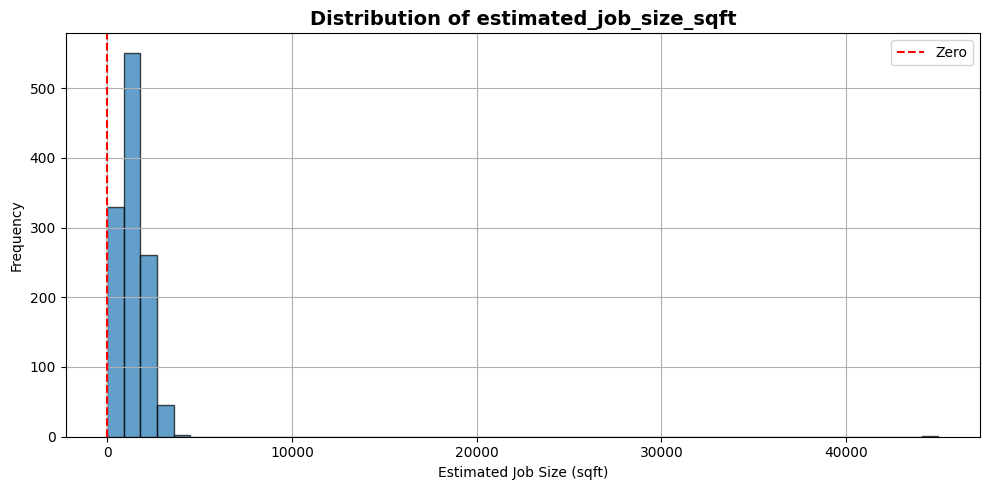

Min: 0.0, Max: 45000.0
Rows with 0 sqft: 2


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
df["estimated_job_size_sqft"].dropna().hist(bins=50, ax=ax, edgecolor="black", alpha=0.7)
ax.set_title("Distribution of estimated_job_size_sqft", fontsize=14, fontweight="bold")
ax.set_xlabel("Estimated Job Size (sqft)")
ax.set_ylabel("Frequency")
ax.axvline(0, color="red", linestyle="--", label="Zero")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min: {df['estimated_job_size_sqft'].min()}, Max: {df['estimated_job_size_sqft'].max()}")
print(f"Rows with 0 sqft: {(df['estimated_job_size_sqft'] == 0).sum()}")

### 1.3 Box Plot of estimated_job_size_sqft
Visually flag outliers before we decide how to handle missing values.

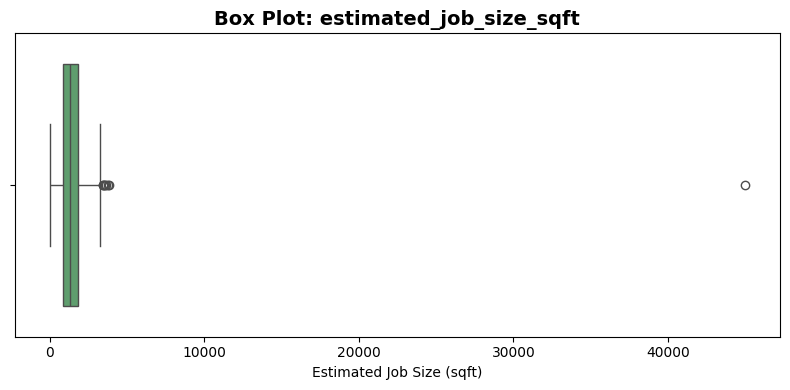

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df["estimated_job_size_sqft"].dropna(), ax=ax, color="#55A868")
ax.set_title("Box Plot: estimated_job_size_sqft", fontsize=14, fontweight="bold")
ax.set_xlabel("Estimated Job Size (sqft)")
plt.tight_layout()
plt.show()

### 1.4 Distribution of distance_to_queens_km
Same check — are there impossible values or extreme outliers?

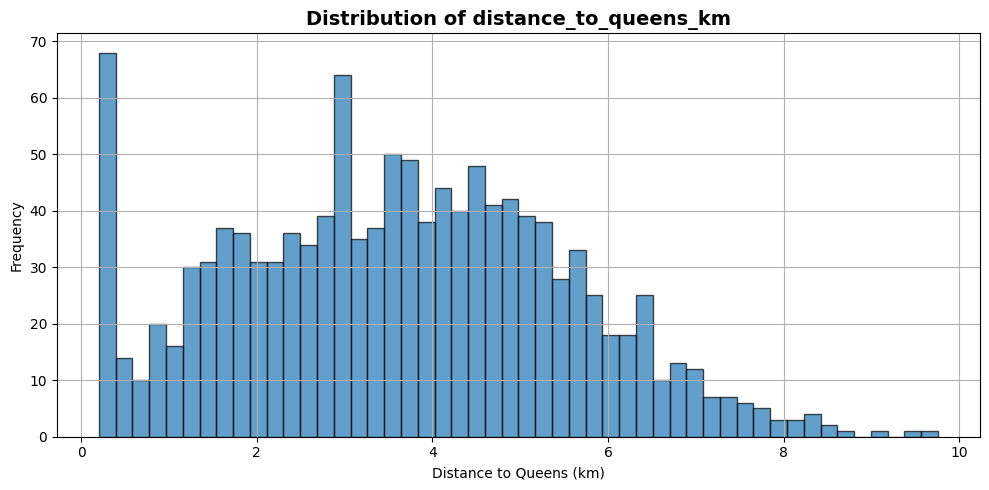

Min: 0.2, Max: 9.76


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
df["distance_to_queens_km"].dropna().hist(bins=50, ax=ax, edgecolor="black", alpha=0.7)
ax.set_title("Distribution of distance_to_queens_km", fontsize=14, fontweight="bold")
ax.set_xlabel("Distance to Queens (km)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Min: {df['distance_to_queens_km'].min()}, Max: {df['distance_to_queens_km'].max()}")

### 1.5 Unique Value Counts for Categorical Columns
This is how we spot dirty duplicates like `'Door 2 Door'` vs `'Door-to-Door'`, `'FaceBook'` vs `'Facebook Ads'`, or `'Westend'` vs `'West End'`.

In [21]:
cat_cols = [
    "referral_source",
    "homeowner_status",
    "property_type",
    "requested_timeline",
    "neighbourhood",
    "customer_age_bracket",
]

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col} — {df[col].nunique()} unique values")
    print("="*50)
    print(df[col].value_counts(dropna=False).to_string())


referral_source — 8 unique values
referral_source
Facebook Ads              510
Lawn Signs                275
Door-to-Door              248
Word of Mouth/Referral    152
FaceBook                   31
Door 2 Door                14
LawnSign                   12
Word-of-mouth               8

homeowner_status — 3 unique values
homeowner_status
Own                   885
Rent                  236
Recently Purchased    129

property_type — 5 unique values
property_type
Detached         455
Apartment        263
Townhouse        236
Semi-Detached    228
Heritage Home     68

requested_timeline — 4 unique values
requested_timeline
Flexible     336
1-2 weeks    326
1 month      319
ASAP         269

neighbourhood — 12 unique values
neighbourhood
West End              316
Downtown              248
Sydenham Ward         189
Strathcona Park       164
Calvin Park           155
Portsmouth Village    116
Down Town              21
Portsmoth Village      11
Westend                10
Sydenhamm Ward     

---
## Imputation Strategy Analysis
Before blindly filling missing values, we test whether the features we'd use for imputation actually correlate with the target. This section determines the right strategy for each column, then executes it.

In [22]:
# Reload raw data for a clean starting point
df = pd.read_csv("leads.csv")
ORIGINAL_ROW_COUNT = len(df)
cleaning_log = []  # track (step_name, rows_removed)

# --- Pre-requisite cleaning ---
# Fix lead_date (mixed formats)
df["lead_date"] = pd.to_datetime(df["lead_date"], format="mixed", dayfirst=False)

# Standardize referral_source
referral_map = {
    "FaceBook": "Facebook Ads",
    "Door 2 Door": "Door-to-Door",
    "LawnSign": "Lawn Signs",
    "Word-of-mouth": "Word of Mouth/Referral",
}
df["referral_source"] = df["referral_source"].replace(referral_map)

# Standardize neighbourhood (needed for group-wise imputation)
df["neighbourhood"] = df["neighbourhood"].str.strip()
neighbourhood_map = {
    "Down Town": "Downtown",
    "Westend": "West End",
    "Sydenhamm Ward": "Sydenham Ward",
    "Portsmoth Village": "Portsmouth Village",
    "Strathcona Prk": "Strathcona Park",
}
df["neighbourhood"] = df["neighbourhood"].replace(neighbourhood_map)

print(f"Starting rows: {ORIGINAL_ROW_COUNT}")
print(f"lead_date dtype: {df['lead_date'].dtype}")
print(f"Unique referral sources: {sorted(df['referral_source'].unique())}")
print(f"Unique neighbourhoods: {sorted(df['neighbourhood'].unique())}")

Starting rows: 1250
lead_date dtype: datetime64[ns]
Unique referral sources: ['Door-to-Door', 'Facebook Ads', 'Lawn Signs', 'Word of Mouth/Referral']
Unique neighbourhoods: ['Calvin Park', 'Downtown', 'Portsmouth Village', 'Strathcona Park', 'Sydenham Ward', 'West End']


### 1. Outlier Treatment for estimated_job_size_sqft
Values of **0 sqft** (impossible — no job has zero area) and **above 5000 sqft** (extreme for the residential leads in this dataset) are treated as data entry errors. We replace them with NaN **before** computing neighbourhood medians so outliers don't contaminate the imputation.

In [23]:
n_zero = (df["estimated_job_size_sqft"] == 0).sum()
n_over_5000 = (df["estimated_job_size_sqft"] > 5000).sum()
print(f"Rows with 0 sqft: {n_zero}")
print(f"Rows with > 5000 sqft: {n_over_5000}")

# Replace outliers with NaN
df.loc[df["estimated_job_size_sqft"] == 0, "estimated_job_size_sqft"] = np.nan
df.loc[df["estimated_job_size_sqft"] > 5000, "estimated_job_size_sqft"] = np.nan

total_missing_sqft = df["estimated_job_size_sqft"].isna().sum()
print(f"\nTotal missing estimated_job_size_sqft (original + outliers): {total_missing_sqft}")
print(f"Valid job-size range: {df['estimated_job_size_sqft'].min():.0f} – {df['estimated_job_size_sqft'].max():.0f} sqft")

Rows with 0 sqft: 2
Rows with > 5000 sqft: 1

Total missing estimated_job_size_sqft (original + outliers): 63
Valid job-size range: 150 – 3835 sqft


### 2. Neighbourhood vs Job Size Correlation
If neighbourhood systematically predicts job size, we should impute missing `estimated_job_size_sqft` values using the neighbourhood median rather than dropping rows. We test this with a boxplot, per-neighbourhood means, and a Pearson correlation — computed on **clean values only** (outliers already removed).

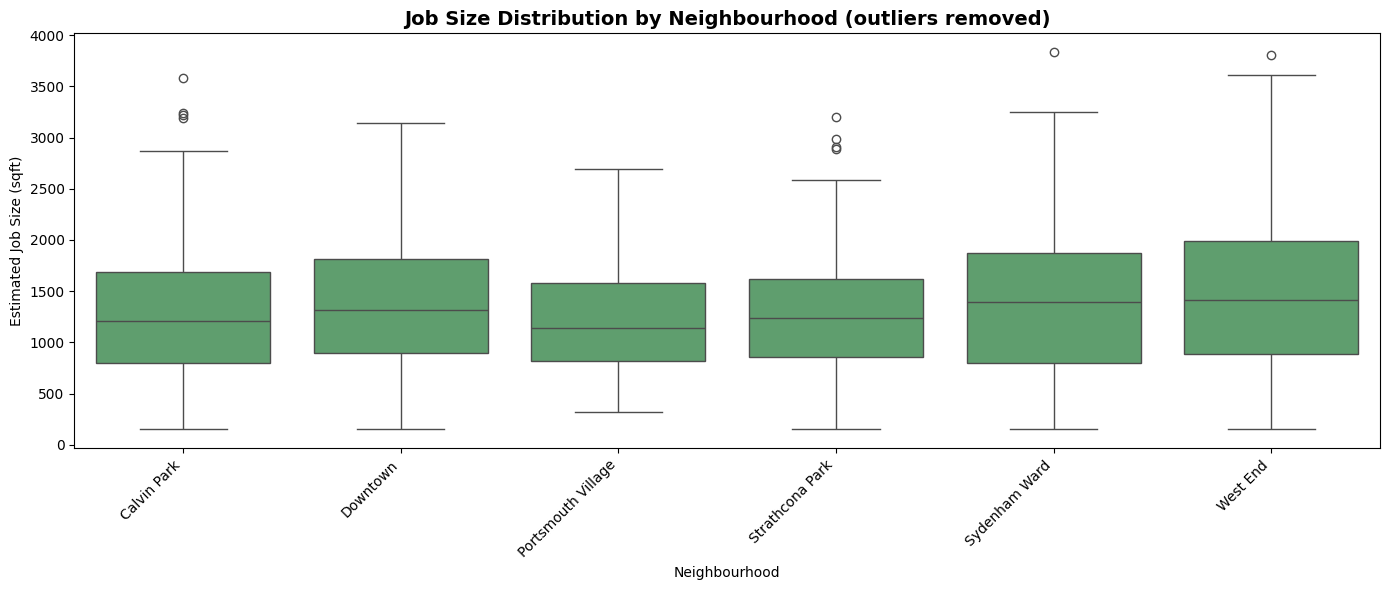


Mean estimated_job_size_sqft per neighbourhood:
neighbourhood
West End              1498.578778
Sydenham Ward         1422.605405
Downtown              1376.393822
Strathcona Park       1305.116564
Calvin Park           1296.543046
Portsmouth Village    1220.161017

Pearson r (label-encoded neighbourhood vs job size): -0.0171
|r| = 0.0171

>>> |r| <= 0.2 — Correlation is too weak for neighbourhood-wise imputation.
>>> Decision: DROP rows with missing job sizes entirely.


In [24]:
# --- Boxplot: job size by neighbourhood ---
fig, ax = plt.subplots(figsize=(14, 6))
plot_data = df.dropna(subset=["estimated_job_size_sqft"])
neighbourhood_order = sorted(plot_data["neighbourhood"].unique())
sns.boxplot(
    data=plot_data,
    x="neighbourhood",
    y="estimated_job_size_sqft",
    order=neighbourhood_order,
    ax=ax,
    color="#55A868",
)
ax.set_title("Job Size Distribution by Neighbourhood (outliers removed)", fontsize=14, fontweight="bold")
ax.set_xlabel("Neighbourhood")
ax.set_ylabel("Estimated Job Size (sqft)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Mean job size per neighbourhood ---
mean_by_neighbourhood = (
    df.groupby("neighbourhood")["estimated_job_size_sqft"]
    .mean()
    .sort_values(ascending=False)
)
print("\nMean estimated_job_size_sqft per neighbourhood:")
print(mean_by_neighbourhood.to_string())

# --- Pearson correlation (label-encoded neighbourhood vs job size) ---
mask = df["estimated_job_size_sqft"].notna()
encoded_neighbourhood = pd.factorize(df.loc[mask, "neighbourhood"])[0]
r = np.corrcoef(encoded_neighbourhood, df.loc[mask, "estimated_job_size_sqft"])[0, 1]

print(f"\nPearson r (label-encoded neighbourhood vs job size): {r:.4f}")
print(f"|r| = {abs(r):.4f}")

USE_NEIGHBOURHOOD_IMPUTATION = abs(r) > 0.2

if USE_NEIGHBOURHOOD_IMPUTATION:
    print("\n>>> |r| > 0.2 — Correlation is meaningful.")
    print(">>> Decision: Fill missing job sizes with the NEIGHBOURHOOD MEDIAN.")
else:
    print("\n>>> |r| <= 0.2 — Correlation is too weak for neighbourhood-wise imputation.")
    print(">>> Decision: DROP rows with missing job sizes entirely.")

### 3. Imputation Decision

We tested the Pearson correlation between neighbourhood and `estimated_job_size_sqft`. The result was **r = -0.017**, which is far below our |r| > 0.2 threshold. This means neighbourhood has no meaningful predictive relationship with job size — imputing with neighbourhood medians would inject false signal into the data.

**Decision:** Rows with missing or invalid job sizes are dropped entirely.

In [25]:
n_missing_sqft = df["estimated_job_size_sqft"].isna().sum()
print(f"Missing estimated_job_size_sqft (incl. outliers): {n_missing_sqft}")

if USE_NEIGHBOURHOOD_IMPUTATION:
    neighbourhood_medians = df.groupby("neighbourhood")["estimated_job_size_sqft"].transform("median")
    df["estimated_job_size_sqft"] = df["estimated_job_size_sqft"].fillna(neighbourhood_medians)
    # Fallback to global median if a neighbourhood had ALL nulls
    global_median = df["estimated_job_size_sqft"].median()
    df["estimated_job_size_sqft"] = df["estimated_job_size_sqft"].fillna(global_median)
    print(f"Filled {n_missing_sqft} missing values using neighbourhood medians.")
else:
    before = len(df)
    df = df.dropna(subset=["estimated_job_size_sqft"])
    dropped = before - len(df)
    cleaning_log.append(("Drop missing estimated_job_size_sqft", dropped))
    print(f"Dropped {dropped} rows with missing job size.")

print(f"Missing estimated_job_size_sqft after: {df['estimated_job_size_sqft'].isna().sum()}")
print(f"Job size range: {df['estimated_job_size_sqft'].min():.0f} – {df['estimated_job_size_sqft'].max():.0f} sqft")

Missing estimated_job_size_sqft (incl. outliers): 63
Dropped 63 rows with missing job size.
Missing estimated_job_size_sqft after: 0
Job size range: 150 – 3835 sqft


### 4. Impute missing distance_to_queens_km
Fill missing distances using the median distance within the same neighbourhood group. This makes geographic sense — leads from the same neighbourhood should be a similar distance from Queens.

In [26]:
n_missing_dist = df["distance_to_queens_km"].isna().sum()
print(f"Missing distance_to_queens_km before: {n_missing_dist}")

# Per-neighbourhood median distances
dist_medians_table = (
    df.groupby("neighbourhood")["distance_to_queens_km"]
    .median()
    .sort_values()
)
print("\nPer-neighbourhood median distances used for imputation:")
print(dist_medians_table.to_string())

# Fill
neighbourhood_dist_medians = df.groupby("neighbourhood")["distance_to_queens_km"].transform("median")
df["distance_to_queens_km"] = df["distance_to_queens_km"].fillna(neighbourhood_dist_medians)
# Global fallback
df["distance_to_queens_km"] = df["distance_to_queens_km"].fillna(df["distance_to_queens_km"].median())

print(f"\nMissing distance_to_queens_km after: {df['distance_to_queens_km'].isna().sum()}")

Missing distance_to_queens_km before: 28

Per-neighbourhood median distances used for imputation:
neighbourhood
Downtown              3.460
Portsmouth Village    3.525
Calvin Park           3.595
Sydenham Ward         3.600
West End              3.680
Strathcona Park       3.720

Missing distance_to_queens_km after: 0


### 5. Does preferred_contact predict profit band?
If the High-profit rate is roughly the same (within 5 percentage points) across all contact preferences, then the column is noise and should be dropped.

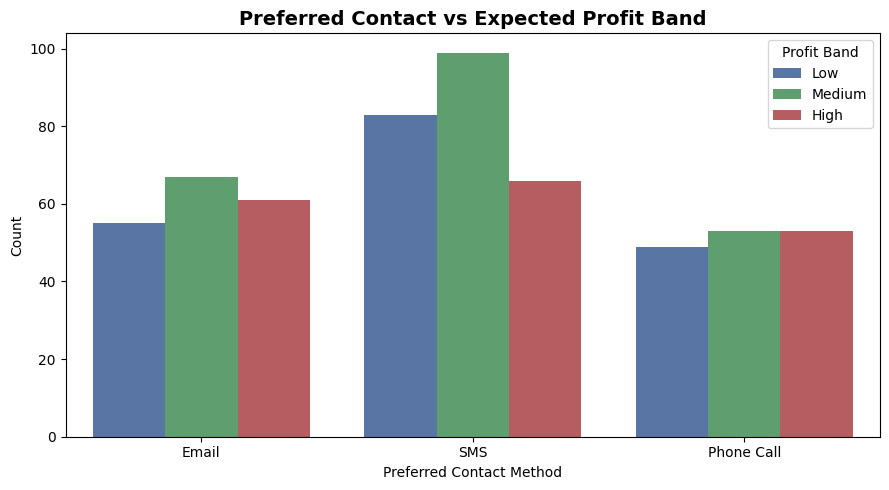


High-profit lead rate by preferred_contact:
  Phone Call           → 34.2%
  Email                → 33.3%
  SMS                  → 26.6%

Spread (max - min): 7.6 percentage points
>>> Spread > 5pp — preferred_contact has predictive signal. Will KEEP this column.


In [27]:
PALETTE = {"Low": "#4C72B0", "Medium": "#55A868", "High": "#C44E52"}
BAND_ORDER = ["Low", "Medium", "High"]

# Only rows that have both a profit band label AND a contact preference
labeled = df.dropna(subset=["expected_profit_band", "preferred_contact"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(
    data=labeled,
    x="preferred_contact",
    hue="expected_profit_band",
    hue_order=BAND_ORDER,
    palette=PALETTE,
    ax=ax,
)
ax.set_title("Preferred Contact vs Expected Profit Band", fontsize=14, fontweight="bold")
ax.set_xlabel("Preferred Contact Method")
ax.set_ylabel("Count")
ax.legend(title="Profit Band")
plt.tight_layout()
plt.show()

# Calculate High-profit rate per contact type
high_rate = (
    labeled.groupby("preferred_contact")["expected_profit_band"]
    .apply(lambda x: (x == "High").mean() * 100)
    .sort_values(ascending=False)
)
print("\nHigh-profit lead rate by preferred_contact:")
for contact, rate in high_rate.items():
    print(f"  {contact:20s} → {rate:.1f}%")

spread = high_rate.max() - high_rate.min()
print(f"\nSpread (max - min): {spread:.1f} percentage points")

DROP_PREFERRED_CONTACT = spread <= 5.0
if DROP_PREFERRED_CONTACT:
    print(">>> Spread ≤ 5pp — preferred_contact is NOISE. Will drop this column.")
else:
    print(">>> Spread > 5pp — preferred_contact has predictive signal. Will KEEP this column.")

### Preferred Contact Conclusion

**If the spread is ≤ 5 pp:** The High-profit rate is virtually identical across Email, Phone Call, and SMS. Contact preference is just noise — it doesn't help predict lead quality. Dropping it simplifies the feature set without losing information.

**If the spread is > 5 pp:** One or more contact methods are associated with meaningfully different profit band distributions. Keeping the column gives downstream models a useful signal.

In [28]:
if DROP_PREFERRED_CONTACT:
    df = df.drop(columns=["preferred_contact"])
    print("Dropped column: preferred_contact (noise).")
else:
    # Drop rows where preferred_contact is missing (keep column)
    before = len(df)
    df = df.dropna(subset=["preferred_contact"])
    dropped = before - len(df)
    cleaning_log.append(("Drop missing preferred_contact", dropped))
    print(f"Kept preferred_contact. Dropped {dropped} rows with missing values.")

Kept preferred_contact. Dropped 24 rows with missing values.


### Drop remaining rows with missing customer_age_bracket

In [29]:
before = len(df)
df = df.dropna(subset=["customer_age_bracket"])
dropped = before - len(df)
cleaning_log.append(("Drop missing customer_age_bracket", dropped))
print(f"Dropped {dropped} rows with missing customer_age_bracket.")

Dropped 20 rows with missing customer_age_bracket.


### Final Cleaning Summary

In [30]:
final_row_count = len(df)
total_removed = ORIGINAL_ROW_COUNT - final_row_count

print("=" * 55)
print("           CLEANING SUMMARY")
print("=" * 55)
print(f"  Original row count:          {ORIGINAL_ROW_COUNT}")
print("-" * 55)
for step_name, n_removed in cleaning_log:
    print(f"  {step_name:40s}  -{n_removed}")
print("-" * 55)
print(f"  Total rows removed:          {total_removed}")
print(f"  Final row count:             {final_row_count}")
print(f"  Retention rate:              {final_row_count / ORIGINAL_ROW_COUNT * 100:.1f}%")
print("=" * 55)

print("\nRemaining missing values:")
print(df.isnull().sum())

           CLEANING SUMMARY
  Original row count:          1250
-------------------------------------------------------
  Drop missing estimated_job_size_sqft      -63
  Drop missing preferred_contact            -24
  Drop missing customer_age_bracket         -20
-------------------------------------------------------
  Total rows removed:          107
  Final row count:             1143
  Retention rate:              91.4%

Remaining missing values:
lead_id                      0
lead_date                    0
property_type                0
neighbourhood                0
estimated_job_size_sqft      0
requested_timeline           0
referral_source              0
homeowner_status             0
preferred_contact            0
lead_capture_weather         0
distance_to_queens_km        0
customer_age_bracket         0
has_pets                     0
lead_weekday                 0
expected_profit_band       567
dtype: int64


### Save Cleaned Data

In [31]:
df.to_csv("leads_cleaned.csv", index=False)
print(f"Saved cleaned data to leads_cleaned.csv ({len(df)} rows)")

Saved cleaned data to leads_cleaned.csv (1143 rows)
